In [27]:
import numpy as np
from PIL import Image
from datasets import load_dataset
import matplotlib.pyplot as plt

ds = load_dataset("nikolkoo/SatelliteSegmentation")

ds

DatasetDict({
    train: Dataset({
        features: ['image', 'mask'],
        num_rows: 790
    })
})

# Problem 1: Exploration

## Sub-Question 1 Response:

The dataset is a dictionary containing 790 pairs of images. These pairs have 1 mask and 1 RGB satellite image each. Every image in every pair is the same size of 256 pixels by 256 pixels.

In [28]:
for k, v in ds['train'][0].items():
    if hasattr(v, 'size'):
        print(f"{k}: PIL Image, size={v.size}, mode={v.mode}")

image: PIL Image, size=(256, 256), mode=RGB
mask: PIL Image, size=(256, 256), mode=L


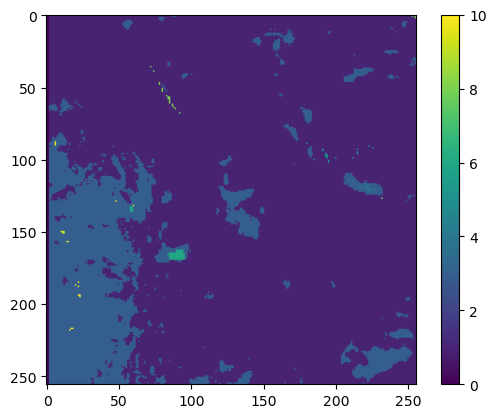

In [29]:
sample = ds['train'][0]['mask']
sample = np.array(sample)
sample = sample//10

plt.imshow(sample)
plt.colorbar()


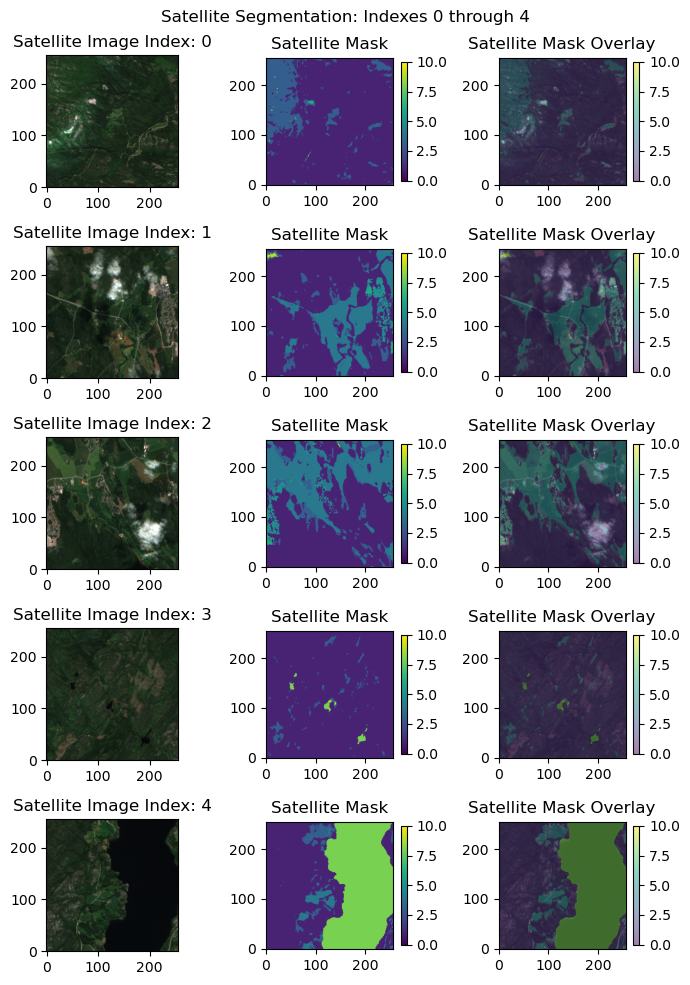

In [30]:
fig, ax = plt.subplots(5, 3, figsize=(7, 10))


for idx in range(0, 5):
    ax[idx][0].imshow(np.array(ds['train'][idx]['image']))
    ax[idx][0].invert_yaxis()
    ax[idx][0].set_title(f"Satellite Image Index: {idx}")


    im = ax[idx][1].imshow(np.array(ds['train'][idx]['mask'])//10, vmin=0, vmax=10)
    ax[idx][1].invert_yaxis()
    fig.colorbar(im, ax=ax[idx][1], shrink=0.9)
    ax[idx][1].set_title("Satellite Mask")

    ax[idx][2].imshow(np.array(ds['train'][idx]['image']))
    im2 = ax[idx][2].imshow(np.array(ds['train'][idx]['mask'])//10, alpha=0.5, vmin=0, vmax=10)
    ax[idx][2].invert_yaxis()
    fig.colorbar(im2, ax=ax[idx][2], shrink=0.9)
    ax[idx][2].set_title("Satellite Mask Overlay")


plt.suptitle("Satellite Segmentation: Indexes 0 through 4")
plt.tight_layout()
plt.show()

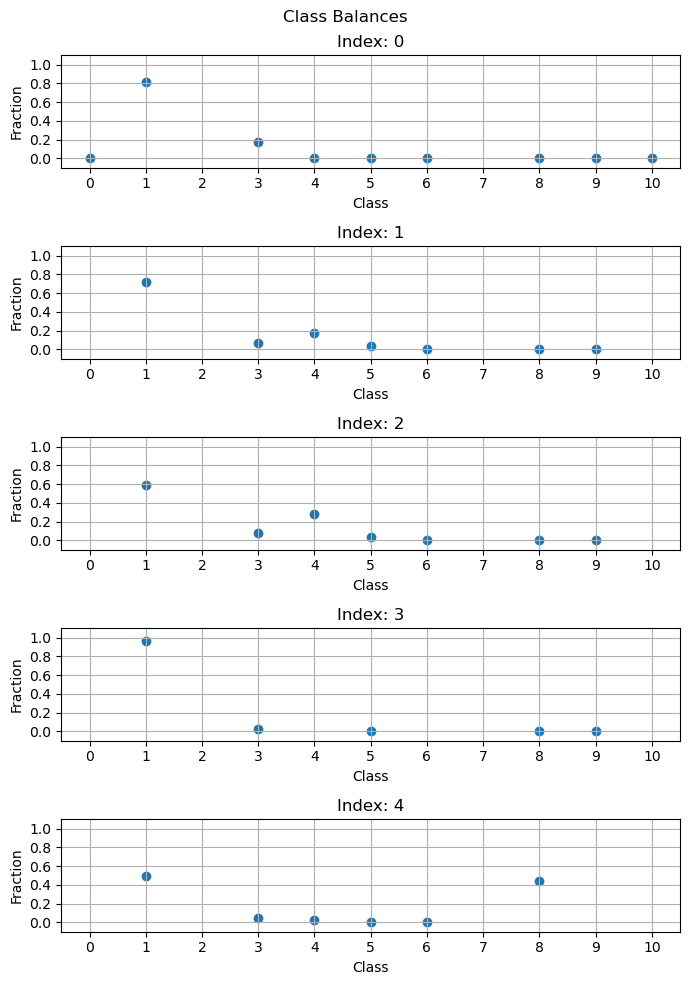

In [31]:
fig, ax = plt.subplots(5, 1, figsize=(7, 10))


for idx in range(0, 5):
    arr = np.array(ds['train'][idx]['mask'])//10
    max = arr.flatten().shape[0]
    unq = np.unique(arr)
    cnts = np.array([])
    for val in unq:
        cnt = (arr == val).sum()
        cnts = np.append(cnts, cnt)

    cnts = cnts / max


    ax[idx].scatter(unq, cnts)
    ax[idx].set_xlim(-0.5, 10.5)
    ax[idx].set_xticks(np.arange(0, 11, 1))
    ax[idx].set_xticklabels(np.arange(0, 11, 1))
    ax[idx].set_ylim(-0.1, 1.1)
    ax[idx].set_yticks(np.arange(0, 1.2, 0.2))

    ax[idx].grid()
    ax[idx].set_title(f"Index: {idx}")
    ax[idx].set_xlabel("Class")
    ax[idx].set_ylabel("Fraction")


plt.suptitle("Class Balances")
plt.tight_layout()
plt.show()

## Sub-question 2 response:

With just the first 5 map examples the algorithm will learn only the classes it is presented with. For example from this subset the algorithm should be able to learn class 1 fairly easily as there is a lot of examples for it to learn from, but class 0 will be much more difficult as it practically doesn't show up. (except for the index 0 case) In the above graphs if a class doesn't have a plot marker, it doesn't appear in the indexes example.

In [32]:
np.array(ds['train']['mask'][0]).shape

(256, 256)

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import numpy as np

class SatelliteSegmentation(Dataset):
    def __init__(self, data_list, image_size=(256, 256)):
        """
        Args:

        """
        self.data_list = data_list
        self.image_size = image_size
    def __len__(self):
        return len(self.data_list)
    def _to_tensor_image(self, image):

        if isinstance(image, np.ndarray):
            image = np.array(image)
            image = torch.from_numpy(image)
        elif not isinstance(image, torch.Tensor):
            image = np.array(image)
            image = torch.tensor(image)


        if image.ndim == 3:
            if image.shape[-1] == 3:
                image = image.permute(2,0,1) # Convert H, W, 3 to 3, H, W
            elif image.shape[0] == 3:
                pass
            else:
                raise ValueError(f"Bad Image Shape: {image.shape}")
        else:
            raise ValueError(f"Bad Image Dimensions [NEED 3]: {image.shape}")

        if image.max() > 1.0:
            image = image / 255.0 # RGB Scaling from 0 to 255 to 0 to 1

        image = F.interpolate(image.unsqueeze(0), size=self.image_size, mode="bilinear", align_corners=False).squeeze(0)
        return image

    def _to_tensor_mask(self, mask):
        mask = np.array(mask) // 10
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask)
        elif not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask)

        if mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.squeeze(-1)
        elif mask.ndim == 3 and mask.shape[0] == 1:
            mask = mask.squeeze(-1)

        if mask.ndim != 2:
            raise ValueError(f"Mask must have shape of H,W and got {mask.shape}")

        mask = mask.unsqueeze(0).unsqueeze(0).to(torch.float32)
        mask = F.interpolate(mask, size=self.image_size, mode="nearest", align_corners=None).squeeze(0).squeeze(0)
        return mask

    def __getitem__(self, idx):
        sample = self.data_list[idx]
        image = self._to_tensor_image(sample['image'])
        mask = self._to_tensor_mask(sample['mask'])
        return image, mask


In [34]:
data_pairs = ds['train']
full_dataset = SatelliteSegmentation(data_pairs, image_size=(256, 256))

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

generator = torch.Generator().manual_seed(42)  # Answer to life, the universe, and everything

train_dataset, val_dataset = random_split(full_dataset, (train_size, val_size), generator=generator)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

In [35]:
print(f"Total samples: {total_size}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Check one batch
images, masks = next(iter(train_loader))
print("Image batch shape:", images.shape)   # (B, 3, 256, 256)
print("Mask batch shape:", masks.shape)     # (B, 256, 256)
print("Image dtype:", images.dtype)         # torch.float32
print("Mask dtype:", masks.dtype)           # torch.int64


Total samples: 790
Training samples: 632
Validation samples: 158
Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32


# Problem 2: Model Design for U-Net Architecture

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as f

class DoubleConv(nn.Module):
    """
    Uses 2 consecutie convolutions (3x3 filter) and follows it with a normalization over the batch and uses ReLU activation (as seen in class). Spatial dimension preservation by adding padding=1.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__() # Makes sure things are correctly pulled in from __init__ in this class.
        self.block = (
            nn.Sequential(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1,bias = False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True), # End of First Pass

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1,bias = False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True) # End of Second pass
            ))

    def forward(self, x):
        return self.block(x)

class down_sample(nn.Module):
    """
    This class only handles downsampling.

    MaxPool -> Double Convolution
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self, x):
        return self.block(x)


class up_sample(nn.Module):
    """
    This Class only handles upsampling.

    Transpose -> skip connection -> double convolution
    """

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)

        if diff_y != 0 or diff_x != 0:
            x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y// 2, diff_y - diff_y // 2])

        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

class UNET(nn.Module):
    """
    U-Net Architecture

    In - (B, 3, H, W)

    Out - (B, C, H, W) tensor of logits: Per Pixel!
    """

    def __init__(self, in_channels = 3, num_classes = 2, base_channels = 64):
        super().__init__()
        self.in_conv = DoubleConv(in_channels, base_channels)

        self.down1 = down_sample(base_channels, base_channels * 2)
        self.down2 = down_sample(base_channels * 2, base_channels * 4)
        self.down3 = down_sample(base_channels * 4, base_channels * 8)
        self.down4 = down_sample(base_channels * 8, base_channels * 16)

        self.up1 = up_sample(base_channels * 16, base_channels * 8, base_channels * 8)
        self.up2 = up_sample(base_channels * 8, base_channels * 4, base_channels * 4)
        self.up3 = up_sample(base_channels * 4, base_channels * 2, base_channels * 2)
        self.up4 = up_sample(base_channels * 2, base_channels, base_channels)

        self.out_conv = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Encode:
        x1 = self.in_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)


        # Decode
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        logits = self.out_conv(x) # Output (Hopefully B,C,H,W
        return logits


In [59]:
classes = 11

model = UNET(in_channels = 3, num_classes = classes).to(device)

x = torch.randn(8, 3, 256, 256).to(device)  # Check that the model works with random fill numbers
y = model(x)

print("Input Shape:", x.shape)   # B, 3, H, W
print("Output Shape:", y.shape)  # B, C, H, W

# For Question response calculate the total number of trainable params:

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTrainable Params: {num_params}")

Input Shape: torch.Size([8, 3, 256, 256])
Output Shape: torch.Size([8, 11, 256, 256])

Trainable Params: 31038283


## Question 2 Justifications

The U-Net architecture is appropriate for sematic segmentation as it predicts a class label for every individual pixel. Thus, each pixel can be identified separately rather than having one single label for the entire image (as a normal CNN would). The skip connections are very critical as they pass high-resolution feature information from the encoder directly to the decoder. This helps to recover fine-resolution boundaries that would be lost through the pooling stage of the convolution.

The total number of thr trainable parameters in my model is 31,038,283 which was given from the above section.

# Problem 3: Training

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def compute_class_weights(dataloader, classes, device):
    class_counts = torch.zeros(classes, dtype=torch.float32)

    for _, masks in dataloader:
        masks = masks.view(-1).to(torch.int)
        counts = torch.bincount(masks, minlength=classes).to(torch.float32)
        class_counts += counts

    class_counts[class_counts == 0] = 1.0

    total_pixels = sum(class_counts)

    weights = total_pixels / (classes * class_counts)  # Inverse weighting that was wanted in the problem: total pixels / C*pixels of class C

    # weights = weights / weights.sum() # Normalize Weights (Implement if needed)

    return weights.to(torch.float32).to(device)

class_weights = compute_class_weights(train_loader, classes, device)
print(f"The Class Weights are: {class_weights}")

class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


def compute_mean_IoU(logits, masks, classes):
    preds = torch.argmax(logits, dim=1)

    ious = []

    for cls in range(classes):
        pred_cls = (preds == cls)
        true_cls = (masks == cls)

        intersection = (pred_cls & true_cls).sum().item()
        union = (pred_cls | true_cls).sum().item()

        if union > 0:
            ious.append(intersection / union)

        if len(ious) == 0:
            return 0.0

        return sum(ious) / len(ious)

train_loss = []
val_loss = []
val_mIoU = []

epochs = 21  # Have at least 20 epochs for training

# Training Loop

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device, dtype=torch.float32)
        masks = masks.to(device, dtype=torch.long)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)

    train_loss.append(epoch_loss)

    # Validation Loop

    model.eval()
    running_val_loss = 0.0
    running_val_mIoU = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device, dtype=torch.float32)
            masks = masks.to(device, dtype=torch.long)

            logits = model(images)
            loss = criterion(logits, masks)

            running_val_loss += loss.item() * images.size(0)
            running_val_mIoU += compute_mean_IoU(logits, masks, classes) * images.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        epoch_val_mIoU = running_val_mIoU / len(val_loader.dataset)

        val_loss.append(epoch_val_loss)
        val_mIoU.append(epoch_val_mIoU)

        print(f"----------------------------------------"
              f"Epoch           : {epoch +1}/{epochs}\n"
              f"Train Loss      : {epoch_loss:.4f}\n"
              f"Validation Loss : {epoch_val_loss:.4f}\n"
              f"Validation mIoU : {epoch_val_mIoU:.4f}")

The Class Weights are: tensor([4.0857e+02, 1.2795e-01, 3.5256e+03, 1.0013e+00, 1.2779e+00, 2.4476e+00,
        5.3572e+01, 1.3448e+05, 1.0419e+00, 1.1340e+02, 2.1596e+02],
       device='cuda:0')


## Problem 3 Plots

In [ ]:
epochs = range(1, epochs)

plt.figure(figsize = (10,10))
plt.plot(epochs, train_loss, 'r', label = 'Training Loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize = (10,10))
plt.plot(epochs, val_mIoU, 'r', label = 'Validation mIoU')
plt.xlabel('Epochs')
plt.ylabel('Validation mIoU')
plt.title('Validation mIoU vs. Epoch')
plt.legend()
plt.grid(True)
plt.show()
